# Random Forests

In [63]:
from typing import Optional, Optional, Union
import pandas as pd
from sklearn.calibration import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    explained_variance_score,
    r2_score,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV

import numpy as np

# Read dataset
data = pd.read_csv("data/dataset.csv")

# Dataset columns by type for preprocessing
binary_cols = [
    "is_driver",
    "is_public_holiday",
    "is_weekday"
]
gender_cols = ["gender"]
time_col = ["time_of_day"]
severity_col = ["severity"]
numeric = ["age", "temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "hour", "day", "month", "year"]
one_hot_cols = ["vehicle_type", "accident_type"]

# Preprocessors
gender_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["male", "female", "unknown"]], dtype=int))
])

time_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["morning", "afternoon", "evening", "night", "unknown"]], dtype=int))
])
severity_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["none", "minor", "serious", "fatal", "unknown"]], dtype=int))
])

binary_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
])

numeric_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

one_hot_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# Hyperparameter tuning helper functions
def get_best_classifier(pipeline, x_train, y_train, param_grid = None):
    if param_grid is None:
        param_grid = {
            "classifier__n_estimators": [300, 500, 800],
            "classifier__max_depth": [None, 10, 20, 40],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 5],
            "classifier__max_features": ["sqrt", "log2", 1],
        }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",   # good for imbalanced multiclass
        cv=5,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(x_train, y_train)

    print("Best parameters:")
    print(grid_search.best_params_)
    return grid_search.best_estimator_
RandomForestRegressor()
def get_best_regressor(pipeline, x_train, y_train, param_grid = None):
    if param_grid is None:
        param_grid = {
            "regressor__n_estimators": [300, 500, 800, 1000],
            "regressor__max_depth": [None, 10, 30, 50],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 5],
            "regressor__max_features": ["sqrt", "log2", 1],
        }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(x_train, y_train)

    print("Best parameters:")
    print(grid_search.best_params_)
    return grid_search.best_estimator_

def display_roc_curve(y_test, y_proba, n_classes, label: Optional[Union[str, list[str]]]=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    # If binary classification
    if n_classes == 2:
        # If y_proba is (n_samples, 2), take positive class
        if y_proba.ndim == 2:
            y_score = y_proba[:, 1]
        else:
            y_score = y_proba

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        label = label if label else "Positive class"

        ax.plot(
            fpr,
            tpr,
            label=f"{label} (AUC = {roc_auc:.3f})"
        )
    else:
        fpr = {}
        tpr = {}
        roc_auc = {}

        y_test_bin = label_binarize(y_test, classes=range(n_classes))

        if label is None:
            label = [f"Class {i}" for i in range(n_classes)]

        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

            ax.plot(
                fpr[i],
                tpr[i],
                label=f"{label[i]} (AUC = {roc_auc[i]:.3f})"
            )

    ax.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()

    return fig, ax

# 1. What features predict accident severity?

In [64]:
x_preprocessor = ColumnTransformer(
    transformers=[
        ("gender", gender_encoder, gender_cols),
        ("time_of_day", time_encoder, time_col),
        ("binary", binary_encoder, binary_cols),
        ("numeric", numeric_encoder, numeric),
        ("one_hot", one_hot_encoder, one_hot_cols)
    ]
)

y_preprocessor = ColumnTransformer(
    transformers=[
        ("severity", severity_encoder, severity_col),
    ]
)

rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("classifier", rf)
])

# Remove unknown severities
severity_data = data[~pd.isna(data["severity"])]

vals = severity_data.drop(columns=["severity"])
target = severity_data[severity_col]

y = severity_encoder.fit_transform(target.values.reshape(-1, 1)).ravel()

x_train, x_test, y_train, y_test = train_test_split(vals, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)
print(classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"]))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 800}
              precision    recall  f1-score   support

        none       0.69      0.80      0.74        56
       minor       0.43      0.33      0.38         9
     serious       0.70      0.73      0.71        51
       fatal       0.88      0.41      0.56        17

    accuracy                           0.69       133
   macro avg       0.67      0.57      0.60       133
weighted avg       0.70      0.69      0.68       133



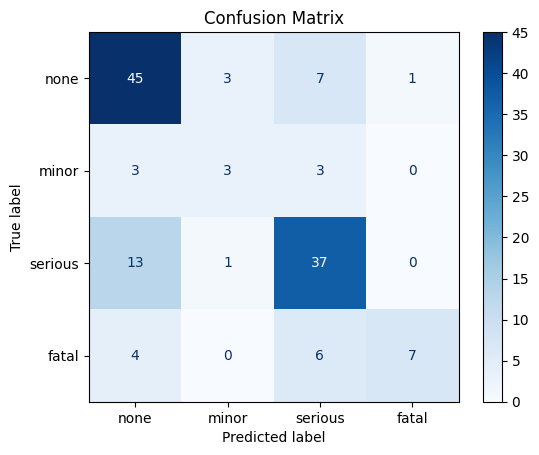

In [66]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=["none", "minor", "serious", "fatal"],
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

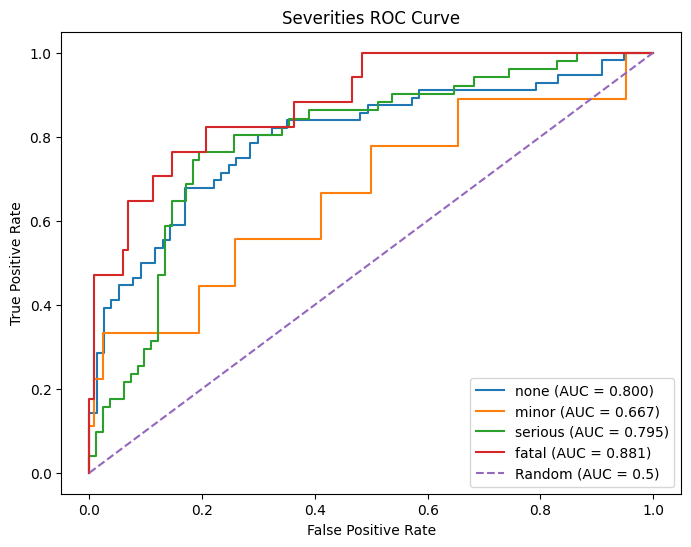

In [67]:
n_classes = len(np.unique(y_test))

y_proba = best_pipeline.predict_proba(x_test)

fig, ax = display_roc_curve(y_test, y_proba, n_classes, label=["none", "minor", "serious", "fatal"])
ax.set_title("Severities ROC Curve")
plt.show()

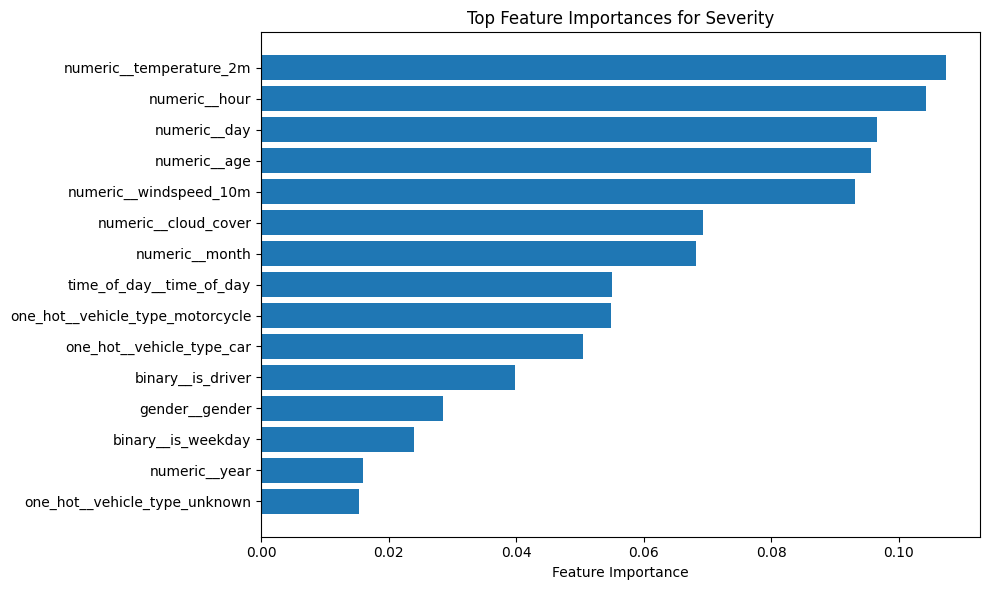

In [68]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Severity")
plt.tight_layout()
plt.show()

c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 20 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


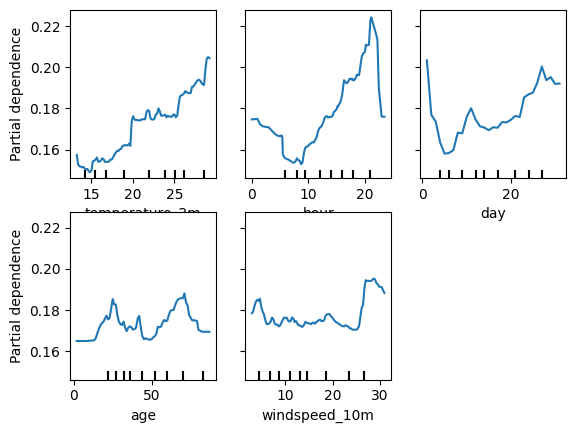

In [69]:
top_feats: list[str] = importance_df.head(5)["feature"].tolist()
top_feats = [feat.split("__", 1)[-1] for feat in top_feats]

# We use a partial dependence plot to visualize the relationship between top features and the target class "fatal" (3)
PartialDependenceDisplay.from_estimator(
    best_pipeline, x_train, top_feats, target=3
)

# Interpretation
## Overall Performance
- Accuracy: 69% shows moderate performance for a 4-class classification over random (25%).
- Weighted F1 Score: 68% shows moderate performace when adjusting for class imbalance.
- Classwise behaviour:
    - None/Serious - These classes are learnt well (0.74 and 0.71 F1 score respectively). This is likely because they represent the majority of cases in the dataset (None - 42% and Serious 38% of dataset).
    - Minor - Low performance (0.38 F1 Score) likely because of low representation in dataset.
    - Fatal - High precision (0.88) but low recall (0.41) means that model is mostly correct when predicting fatal but misses a lot of cases
- Overall model is good at distiguishing between high and low severity cases, but not as effective in determining the exact severity.

## Confusion Matrix
- Fatal and serious confusion is common.
- None and serious are also sometimes confused. Since they are the most represented classes the model most likely learns to predict one or the other most of the time. 
- Minor accidents are often misclassed as none or serious.
- **Implication**: Severity is continuous in nature but since the labels are discrete certain misclassifications happen.

## ROC Curve
- The model is best at ranking fatal accidents over non-fatal, which is valuable for risk prioritisation.

## Feature Importance
- Top Features:
    1. Temperature
    2. Hour of day
    3. Day of month
    4. Age
    5. Wind speed
- **Implication:** Environmental and temporal features are more predictive than demographic features.

## Partial Dependence Plots
- Fatalities increase:
    - With higher temperatures - Could be due to riskier/more reckless driving due to heat.
    - In the evening - Likely due to reduced visibility, emptier roads allows for speeding.
    - At beginning and end of month - May be proxy for pay cycles.
    - Younger drivers (risk taking) and older drivers (frailty).
    - Higher wind speed - May be especially relevant for motorcyclists.

# 2. Can we predict accident occurrence from weather variables?

In [70]:
from datetime import datetime
import requests


url = "https://archive-api.open-meteo.com/v1/archive"

weather_cols = ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "weather_code"]
accident_cols = ["accident_id", "date_time"] + weather_cols
# Aggregate weather data per accident
weather_accident_df = data[accident_cols].groupby("accident_id").aggregate(
    {
        "accident_id": "first",
        "date_time": "first",
        **{col: "mean" for col in weather_cols}
    }
)
weather_accident_df["date"] = pd.to_datetime(weather_accident_df["date_time"]).dt.date

# Get daily accident counts
daily_accidents = (
    weather_accident_df
    .groupby("date")
    .size()
    .reset_index(name="num_accidents")
)

# Binary target
daily_accidents["accident_occurred"] = True

# Getting weather data for missing days from Open-Meteo API
accident_dts = pd.to_datetime(weather_accident_df["date_time"])
start_date = accident_dts.min()
end_date = accident_dts.max()

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

params = {
    "longitude": 14.2135424,
    "latitude": 35.935316,
    "start_date": start_date_str,
    "end_date": end_date_str,
    "hourly": ",".join(weather_cols),
    "timezone": "Europe/Malta"
}
r = requests.get(url, params=params)
weather_data = r.json()

# Create DataFrame from weather data
weather_hourly_df = pd.DataFrame({
    "date_time": pd.to_datetime(weather_data["hourly"]["time"]),
    "temperature_2m": weather_data["hourly"]["temperature_2m"],
    "precipitation": weather_data["hourly"]["precipitation"],
    "windspeed_10m": weather_data["hourly"]["windspeed_10m"],
    "cloud_cover": weather_data["hourly"]["cloud_cover"],
    "weather_code": weather_data["hourly"]["weather_code"],
})

# Aggregate daily weather data
weather_hourly_df["date"] = weather_hourly_df["date_time"].dt.date
daily_weather = (
    weather_hourly_df
    .groupby("date")
    .aggregate({
        "temperature_2m": "mean",
        "precipitation": "mean",
        "windspeed_10m": "mean",
        "cloud_cover": "mean",
        "weather_code": "mean"
    })
    .reset_index()
)

# Add missing days
daily_df = daily_weather.merge(
    daily_accidents[["date", "num_accidents", "accident_occurred"]],
    on="date",
    how="left"
)
# Fill missing values
daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)
daily_df["num_accidents"] = daily_df["num_accidents"].fillna(0).astype(int)

C:\Users\alang\AppData\Local\Temp\ipykernel_24932\1723751060.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)


In [71]:
x_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", numeric_encoder, ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover"]),
    ]
)

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("classifier", rf)
])

In [72]:
vals = daily_df
target = daily_df[["accident_occurred"]]

x_train, x_test, y_train, y_test = train_test_split(vals, target, test_size=0.2, stratify=target, random_state=42)

best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)

print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 1, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 800}


c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

       False       0.47      0.50      0.49        38
        True       0.49      0.46      0.47        39

    accuracy                           0.48        77
   macro avg       0.48      0.48      0.48        77
weighted avg       0.48      0.48      0.48        77



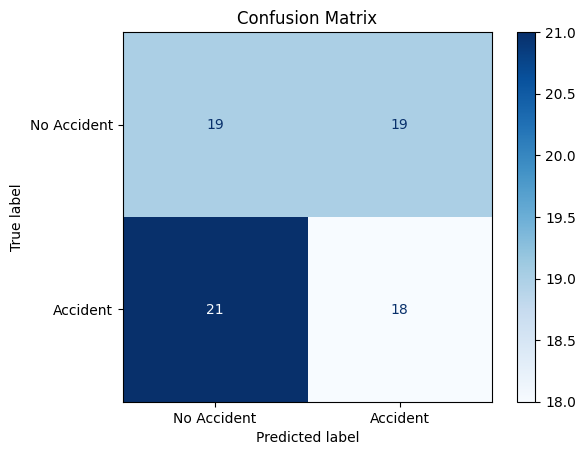

In [73]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=["No Accident", "Accident"],
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

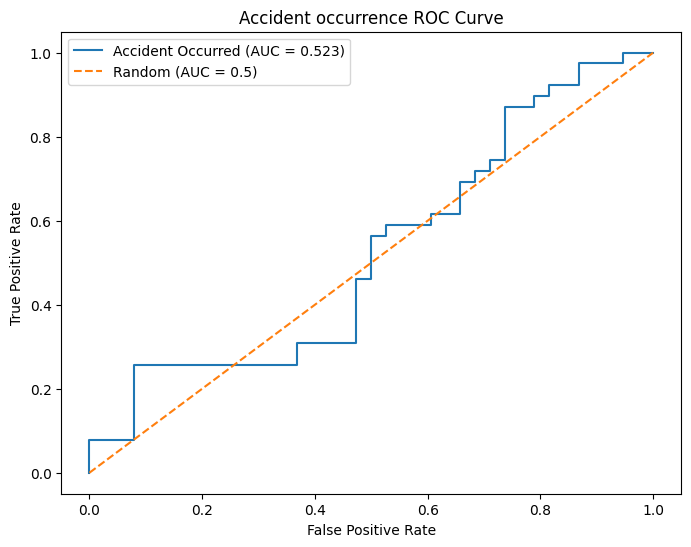

In [74]:
n_classes = len(np.unique(y_test))
y_proba = best_pipeline.predict_proba(x_test)

fig, ax = display_roc_curve(y_test, y_proba, n_classes, label="Accident Occurred")
ax.set_title("Accident occurrence ROC Curve")
plt.show()

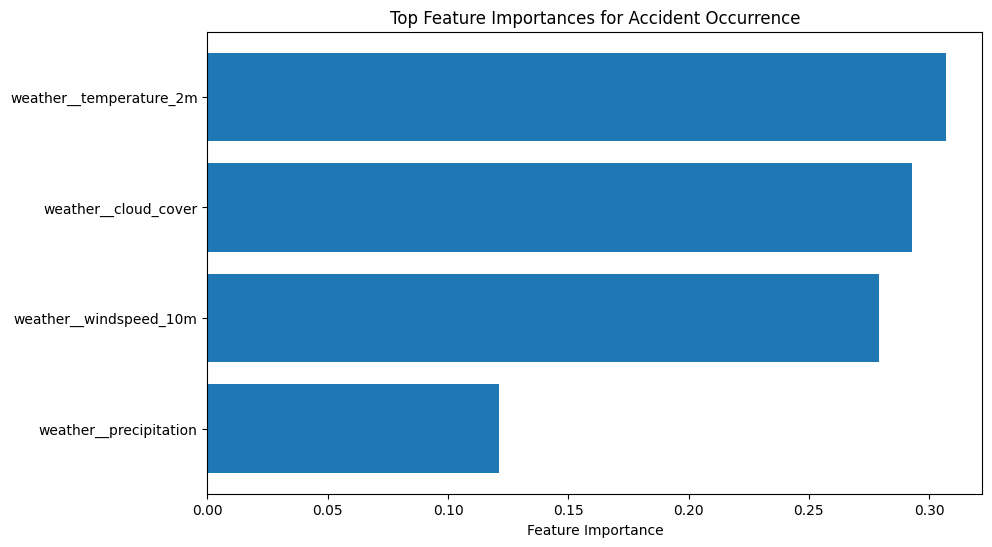

In [75]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Accident Occurrence")
plt.show()

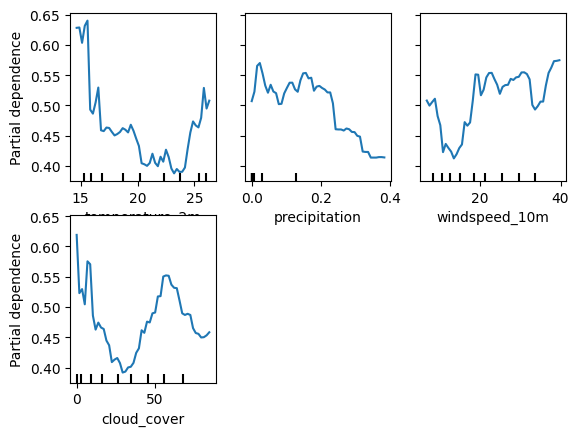

In [76]:
features = [
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "cloud_cover"
]

# Plot partial dependence for weather features
PartialDependenceDisplay.from_estimator(
    best_pipeline,
    x_train,
    features=features,
    grid_resolution=50
)

# Interpretation
## Overall Performance
- Accuracy and F1 Score: 48% shows poor performance for accident occurrence prediction using only weather features.

## Confusion Matrix
- Model misclassifies 50% of non-accident days.
- Model misclassifies accidents incorrectly more often that correctly

## ROC Curve
- ROC Curve closely follows a straight line showing that the model is only slightly better than random. 

## Feature Importance
- Since the model is effectively no better than random, feature importance cannot show any real world relationships.

## Partial Dependence Plots
- Since the model is effectively no better than random, partial dependency plots cannot show any real world relationships.

## Implications
- Weather variables alone are insufficient to predict when accidents are likely to occur. Although weather conditions can influence accident rates, they must be considered alongside additional contextual factors to enable effective prediction.

# 3. Can you predict the severity from personal information?

In [77]:
driver_info_cols = ["age", "gender", "is_driver"]

x_preprocessor = ColumnTransformer(
    transformers=[
        ("gender", gender_encoder, ["gender"]),
        ("binary", binary_encoder, ["is_driver"]),
        ("numeric", numeric_encoder, ["age"]),
    ]
)

y_preprocessor = ColumnTransformer(
    transformers=[
        ("severity", severity_encoder, severity_col),
    ]
)

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("classifier", rf)
])

no_severity = data[~pd.isna(data["severity"])]

vals = no_severity[driver_info_cols]
target = no_severity[severity_col]

# x = x_preprocessor.fit_transform(vals)
y = severity_encoder.fit_transform(target.values.reshape(-1, 1)).ravel()

x_train, x_test, y_train, y_test = train_test_split(vals, y, test_size=0.2, stratify=y, random_state=42)

In [78]:
best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)
print(classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"]))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 800}
              precision    recall  f1-score   support

        none       0.58      0.68      0.62        56
       minor       0.20      0.11      0.14         9
     serious       0.53      0.49      0.51        51
       fatal       0.40      0.35      0.38        17

    accuracy                           0.53       133
   macro avg       0.43      0.41      0.41       133
weighted avg       0.51      0.53      0.52       133



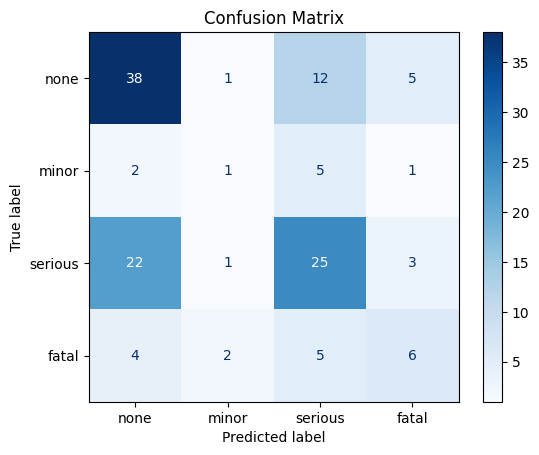

In [79]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=["none", "minor", "serious", "fatal"],
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

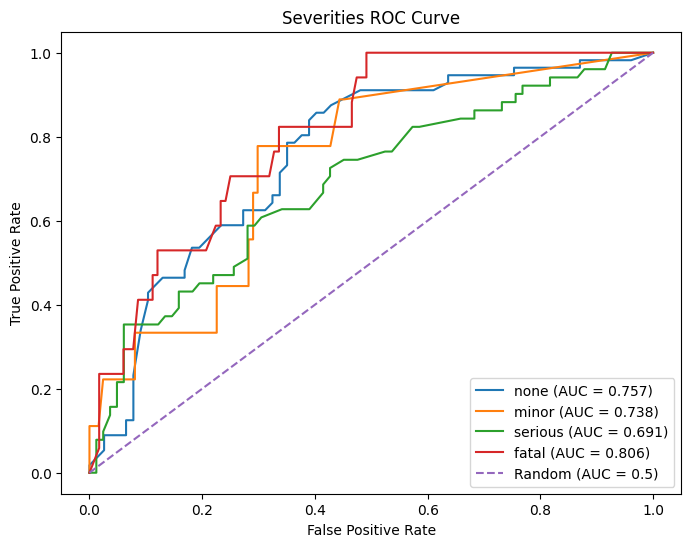

In [80]:
n_classes = len(np.unique(y_test))

y_proba = best_pipeline.predict_proba(x_test)

fig, ax = display_roc_curve(y_test, y_proba, n_classes, label=["none", "minor", "serious", "fatal"])
ax.set_title("Severities ROC Curve")
plt.show()

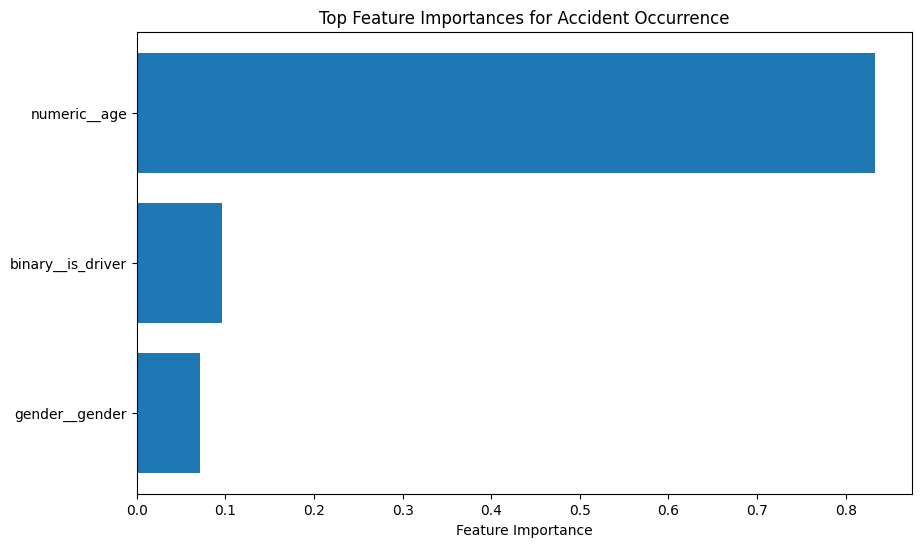

In [81]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Accident Occurrence")
plt.show()

# Interpretation
## Overall Performance
- Accuracy: 53% shows moderate to low performance for a 4-class classification over random (25%).
- Weighted F1 Score: 52% shows moderate to low performace when adjusting for class imbalance.
- Classwise behaviour:
    - None/Serious - Similar to question 1, these classes are learnt best, although still have a relatively low score (0.62 and 0.51 F1 score respectively).
    - Minor - Low performance (0.14 F1 Score). Especially low recall means that the model is missing many minor cases.
    - Fatal - Better performance than minor (0.38 F1 Score).

## Confusion Matrix
- Similar to 1, none and serious are confused often. Since they are the most represented classes the model most likely learns to predict one or the other most of the time. 
- Minor accidents are often misclassed as serious.
- Fatal accidents confusion is quite spread out, although it leans towards more serious labels. This implies that personal information can more easily distinguish more severe injuries.  

## ROC Curve
- Similar to 1, the model is best at ranking fatal accidents over non-fatal.

## Feature Importance
- Age is significantly more predictive than gender and is driver. 

## Implications
- Personal information (age, gender, and driver/passenger) alone are not strong predictors of injury severity.

# 4. Can ML models predict weekly accident frequency given the previous week's temporal features?

In [82]:
# Keep only one record per accident
accident_df = (
    data
    .drop_duplicates(subset="accident_id")
    .copy()
)
# Add only date part
accident_df["date"] = pd.to_datetime(accident_df["date_time"]).dt.date
# Add weekend column from weekday column
accident_df["is_weekend"] = ~accident_df["is_weekday"]

# One-hot encode time_of_day
tod_dummies = pd.get_dummies(accident_df["time_of_day"], prefix="tod")
accident_df = pd.concat([accident_df, tod_dummies], axis=1)

# Aggregate daily accidents
daily_accidents = (
    accident_df
    .groupby("date")
    .aggregate({
        "date": "first",
        "is_weekday": "sum",
        "is_weekend": "sum",
        "is_public_holiday": "sum",
        **{col: "sum" for col in tod_dummies.columns}
    })
)

# Add week column (starts on Monday)
daily_accidents["week"] = pd.to_datetime(daily_accidents["date"]).dt.to_period(pd.offsets.Week(weekday=6))

# Aggregate weekly accidents
weekly_accidents = (
    daily_accidents
    .groupby("week")
    .aggregate(
        {
            "date": "first",
            "is_weekday": "sum",
            "is_weekend": "sum",
            "is_public_holiday": "sum",
            **{col: "sum" for col in tod_dummies.columns}
        }
    )
)

# Normalise by number of days
total = weekly_accidents["is_weekday"] + weekly_accidents["is_weekend"]
weekly_accidents["total"] = total
# weekly_accidents["is_weekday"] = weekly_accidents["is_weekday"] / 5
# weekly_accidents["is_weekend"] = weekly_accidents["is_weekend"] / 2
for col in tod_dummies.columns:
    weekly_accidents[col] = weekly_accidents[col] / total

# Add public holidays info
# Taken from https://www.gov.mt/en/About%20Malta/Pages/Public%20Holidays.aspx
public_holidays = [
    "2023-01-01",
    "2023-02-10",
    "2023-03-19",
    "2023-03-31",
    "2023-04-03",
    "2023-05-01",
    "2023-06-07",
    "2023-06-29",
    "2023-08-15",
    "2023-09-08",
    "2023-09-21",
    "2023-10-08",
    "2023-12-13",
    "2023-12-25",
]
public_holidays = pd.to_datetime(public_holidays).strftime("%m-%d")
calendar_df = pd.DataFrame({
    "date": pd.date_range(start=accident_df["date_time"].min(), end=accident_df["date_time"].max(), freq="D")
}) 
calendar_df["month_day"] = calendar_df["date"].dt.strftime("%m-%d")

calendar_df["is_public_holiday"] = calendar_df["month_day"].isin(public_holidays)
calendar_df["week"] = pd.to_datetime(calendar_df["date"]).dt.to_period(pd.offsets.Week(weekday=6)).astype(str)

# Aggregate weekly calendar info
weekly_calendar_df = (
    calendar_df
    .groupby("week")
    .aggregate(
        {
            "is_public_holiday": "sum"
        }
    )
)

# Normalise public holidays
# weekly_accidents["is_public_holiday"] /= weekly_calendar_df["is_public_holiday"].clip(lower=1)
# Insert missing weeks
weekly_accidents = weekly_accidents.reindex(weekly_calendar_df.index)
weekly_accidents = weekly_accidents.fillna(0)
# Set number of public holidays
weekly_accidents["public_holidays"] = weekly_calendar_df["is_public_holiday"]

# Get month from weekly accidents
weekly_accidents["month"] = pd.to_datetime(weekly_accidents["date"]).dt.month
weekly_accidents = weekly_accidents.sort_index()
weekly_accidents["target_next_week"] = weekly_accidents["total"].shift(-1)
weekly_accidents = weekly_accidents.dropna(subset=["target_next_week"])

Distribution of accidents per week:
Mean accidents per week: 6.036363636363636
STD accidents per week: 3.9672905035293216


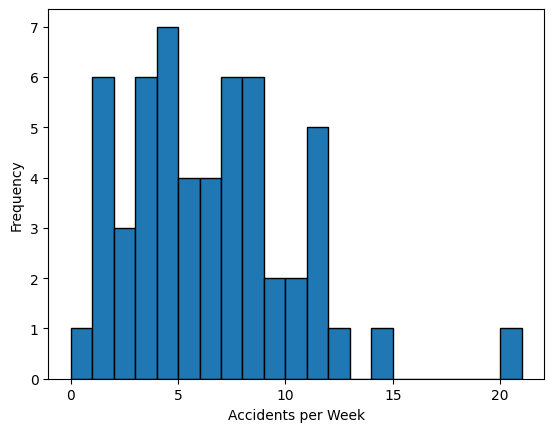

In [83]:
# Plot histogram of accidents per week
print("Distribution of accidents per week:")
print("Mean accidents per week:", weekly_accidents["total"].mean())
print("STD accidents per week:", weekly_accidents["total"].std())
max_accidents = int(weekly_accidents["total"].max())
plt.hist(weekly_accidents["total"], bins=max_accidents, edgecolor="black")
plt.xlabel("Accidents per Week")
plt.ylabel("Frequency")
plt.show()

In [84]:
def regression_report(y_true, y_pred):
    print("Regression Report")
    print("=" * 20)
    print(f"MAE             : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Median AE       : {median_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE            : {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"Explained Var   : {explained_variance_score(y_true, y_pred):.4f}")
    print(f"R²              : {r2_score(y_true, y_pred):.4f}")

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline([
    ("regressor", rf)
])

vals = weekly_accidents[["is_weekday", "is_weekend", "is_public_holiday", "tod_afternoon", "tod_evening", "tod_morning", "tod_night", "public_holidays", "month", "total"]]
target = weekly_accidents[["target_next_week"]]

x_train, x_test, y_train, y_test = train_test_split(vals, target, test_size=0.2, random_state=42)

best_pipeline = get_best_regressor(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)
    
regression_report(y_test, y_pred)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best parameters:
{'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 300}


c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Regression Report
MAE             : 2.3444
Median AE       : 2.3344
RMSE            : 2.7734
Explained Var   : 0.3549
R²              : 0.3399


In [85]:
# Baseline statistics to compare against
y_baseline = np.full_like(y_test, fill_value=weekly_accidents["total"].mean())
regression_report(y_test, y_baseline)

Regression Report
MAE             : 2.6397
Median AE       : 2.0364
RMSE            : 3.4218
Explained Var   : 0.0000
R²              : -0.0048


In [86]:
# Baseline statistics to compare against
y_baseline = x_test["total"]
regression_report(y_test, y_baseline)

Regression Report
MAE             : 3.0000
Median AE       : 3.0000
RMSE            : 3.4245
Explained Var   : -0.0057
R²              : -0.0064


Text(0.5, 1.0, 'Predicted vs Actual')

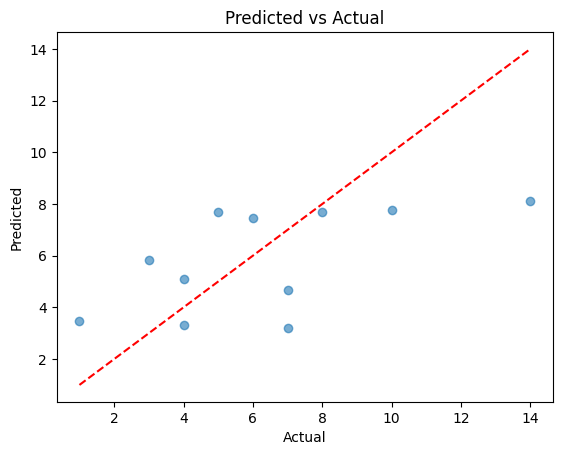

In [87]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

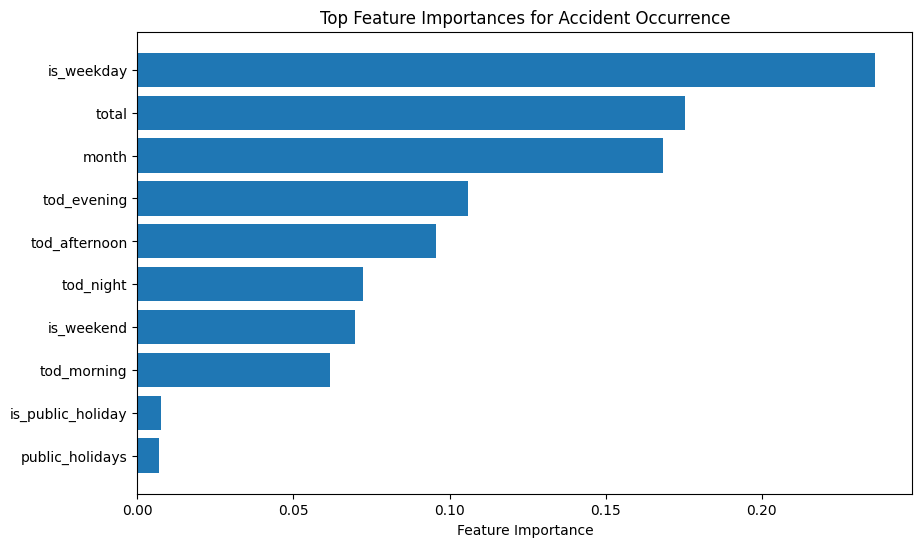

In [88]:
feature_names = list(vals.columns)
importances = best_pipeline.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Accident Occurrence")
plt.show()

## Distribution Context
- The mean number of accidents per week is 6.04, with a standard deviation of 3.97.
- **Implication:** Weekly accident counts exhibit substantial variability, indicating a noisy and challenging prediction task.

## Model Performance
- The model clearly outperforms naive baselines (MAE: 2.34 vs 2.64 for the mean predictor and 3.00 for the current-week total).
- Approximately 35% of the variance in next-week accident counts is explained by the model.
- This represents an 11% reduction in prediction error relative to the mean baseline.

## Predicted vs Actual Plot
- The model predicts low to moderate accident weeks (fewer than 8 accidents) with reasonable accuracy.
- Weeks with exceptionally high accident counts are compressed toward the mean, likely due to the limited representation of high-accident weeks in the data.

## Feature Importance
- The model primarily relies on weekday accident counts, total accidents in the previous week, and the current month.
- The strong influence of weekday and total accident counts indicates temporal persistence, suggesting an autoregressive component in accident frequency.
- The importance of the month variable highlights the presence of seasonal effects.

## Implications
- The results demonstrate that the model can predict weekly accident frequency more accurately than baseline approaches.
- While accident frequency exhibits temporal continuity from week to week, this also suggest that additional contextual factors beyond temporal features are required to fully explain fluctuations in accident counts.